# Airline Passenger Satisfaction - EDA (Refactored)

This notebook demonstrates exploratory data analysis using the modular system.
Instead of having all code inline, we leverage the src modules for clean, reusable code.

## 1. Import Required Libraries

Import necessary libraries and modules from the src package

In [15]:
import sys
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import from src modules
from src.data import DataLoader, DataValidator
from src.utils import logger, grab_col_names, missing_value_analysis, examine_skewness
from src.visualization import Plotter
from src.config import TARGET_COLUMN

# Configure display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

logger.info("Libraries imported successfully")

2026-01-20 18:06:28,247 - src.utils.logger - INFO - Libraries imported successfully


## 2. Load and Validate Data

Use DataLoader to load raw data and DataValidator to check quality

In [16]:
# Load raw data
df_train, df_test = DataLoader.load_raw_data()

logger.info(f"Train data shape: {df_train.shape}")
logger.info(f"Test data shape: {df_test.shape}")

print(f"Training data: {df_train.shape[0]} rows, {df_train.shape[1]} columns")
print(f"Test data: {df_test.shape[0]} rows, {df_test.shape[1]} columns")

2026-01-20 18:06:28,284 - src.utils.logger - INFO - Loading raw training data from C:\Users\punit\Desktop\ML_Project\Analysis of Airline Passenger Satisfaction\data\raw\train.csv
2026-01-20 18:06:28,548 - src.utils.logger - INFO - Loading raw test data from C:\Users\punit\Desktop\ML_Project\Analysis of Airline Passenger Satisfaction\data\raw\test.csv
2026-01-20 18:06:28,621 - src.utils.logger - INFO - Training data shape: (103904, 25)
2026-01-20 18:06:28,623 - src.utils.logger - INFO - Test data shape: (25976, 25)
2026-01-20 18:06:28,630 - src.utils.logger - INFO - Train data shape: (103904, 25)
2026-01-20 18:06:28,632 - src.utils.logger - INFO - Test data shape: (25976, 25)


Training data: 103904 rows, 25 columns
Test data: 25976 rows, 25 columns


## 3. Data Quality Checks

In [17]:
# Check missing values
print("\n=== Missing Values Analysis ===")
missing_train = missing_value_analysis(df_train, include_no_missing=False)
print("\nTrain data missing values:")
print(missing_train)

missing_test = missing_value_analysis(df_test, include_no_missing=False)
print("\nTest data missing values:")
print(missing_test)


=== Missing Values Analysis ===

Train data missing values:
                          count  percentage
Arrival Delay in Minutes    310         0.3

Test data missing values:
                          count  percentage
Arrival Delay in Minutes     83        0.32


In [18]:
# Check duplicates
print("\n=== Duplicate Analysis ===")
train_dups = DataValidator.check_duplicates(df_train)
test_dups = DataValidator.check_duplicates(df_test)
print(f"Duplicates in train: {train_dups}")
print(f"Duplicates in test: {test_dups}")

2026-01-20 18:06:28,832 - src.utils.logger - INFO - No duplicate rows found



=== Duplicate Analysis ===


2026-01-20 18:06:28,858 - src.utils.logger - INFO - No duplicate rows found


Duplicates in train: 0
Duplicates in test: 0


In [19]:
# Validate data shapes
print("\n=== Data Shape Validation ===")
DataValidator.validate_shapes(df_train, df_test)

2026-01-20 18:06:28,882 - src.utils.logger - INFO - Train shape: (103904, 25), Test shape: (25976, 25)



=== Data Shape Validation ===


True

## 4. Column Analysis

Identify and categorize columns

In [20]:
# Grab column information
cat_cols, num_cols, cat_but_car, target_col = grab_col_names(
    df_train, TARGET_COLUMN, print_results=True
)

print(f"\nCategorical columns: {cat_cols}")
print(f"\nNumerical columns: {num_cols}")

2026-01-20 18:06:29,064 - src.utils.logger - INFO - Dataset Analysis:
2026-01-20 18:06:29,067 - src.utils.logger - INFO -   Observations: 103904
2026-01-20 18:06:29,070 - src.utils.logger - INFO -   Variables: 25
2026-01-20 18:06:29,073 - src.utils.logger - INFO -   Categorical Variables: 18
2026-01-20 18:06:29,075 - src.utils.logger - INFO -   Numerical Variables: 6
2026-01-20 18:06:29,077 - src.utils.logger - INFO -   Cardinal Categorical Variables: 0
2026-01-20 18:06:29,078 - src.utils.logger - INFO -   Target Variable: satisfaction



Categorical columns: ['Class', 'Gender', 'Customer Type', 'Type of Travel', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

Numerical columns: ['Arrival Delay in Minutes', 'id', 'Unnamed: 0', 'Age', 'Departure Delay in Minutes', 'Flight Distance']


## 5. Statistical Analysis

Examine skewness, kurtosis, and distributions

In [21]:
# Examine skewness for numerical columns
print("\n=== Distribution Analysis ===")
skewness_analysis = examine_skewness(df_train[num_cols])
print("\nSkewness and Kurtosis Analysis:")
print(skewness_analysis)


=== Distribution Analysis ===

Skewness and Kurtosis Analysis:
                            Skewness    Kurtosis             Skew Type  \
Departure Delay in Minutes  6.733980  100.267006          Right-Skewed   
Arrival Delay in Minutes    6.596637   94.537006          Right-Skewed   
Flight Distance             1.109466    0.268535          Right-Skewed   
id                          0.002864   -1.198440  Approximately Normal   
Unnamed: 0                  0.000000   -1.200000  Approximately Normal   
Age                        -0.004516   -0.719568  Approximately Normal   

                                     Kurtosis Type  
Departure Delay in Minutes  High Kurtosis (Peaked)  
Arrival Delay in Minutes    High Kurtosis (Peaked)  
Flight Distance                Low Kurtosis (Flat)  
id                             Low Kurtosis (Flat)  
Unnamed: 0                     Low Kurtosis (Flat)  
Age                            Low Kurtosis (Flat)  


In [22]:
# Descriptive statistics
print("\n=== Descriptive Statistics (Train) ===")
print(df_train[num_cols].describe().T)


=== Descriptive Statistics (Train) ===
                               count          mean           std   min  \
Arrival Delay in Minutes    103594.0     15.178678     38.698682   0.0   
id                          103904.0  64924.210502  37463.812252   1.0   
Unnamed: 0                  103904.0  51951.500000  29994.645522   0.0   
Age                         103904.0     39.379706     15.114964   7.0   
Departure Delay in Minutes  103904.0     14.815618     38.230901   0.0   
Flight Distance             103904.0   1189.448375    997.147281  31.0   

                                 25%      50%       75%       max  
Arrival Delay in Minutes        0.00      0.0     13.00    1584.0  
id                          32533.75  64856.5  97368.25  129880.0  
Unnamed: 0                  25975.75  51951.5  77927.25  103903.0  
Age                            27.00     40.0     51.00      85.0  
Departure Delay in Minutes      0.00      0.0     12.00    1592.0  
Flight Distance               414

## 6. Visual EDA

Use the Plotter class for comprehensive visualizations

2026-01-20 18:06:29,213 - src.utils.logger - INFO - Plotting numerical feature distributions


Plotting numerical feature distributions...


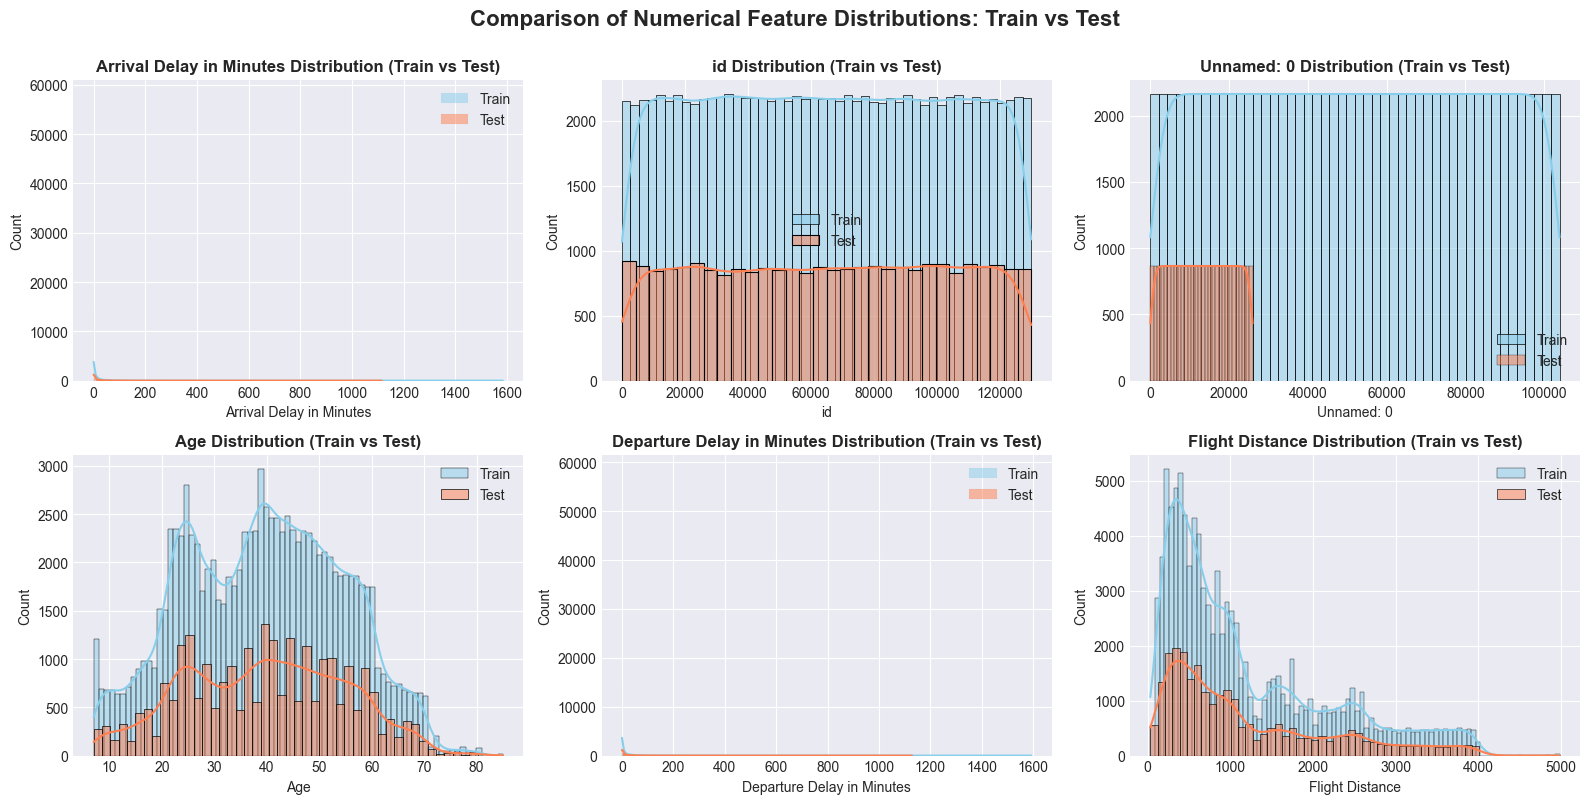

In [23]:
# Plot numerical distributions
print("Plotting numerical feature distributions...")
Plotter.plot_histograms(df_train[num_cols], df_test[num_cols], num_cols, n_cols=3)

2026-01-20 19:08:39,750 - src.utils.logger - INFO - Plotting categorical feature distributions


Plotting categorical feature distributions...


IndexError: index 18 is out of bounds for axis 0 with size 18

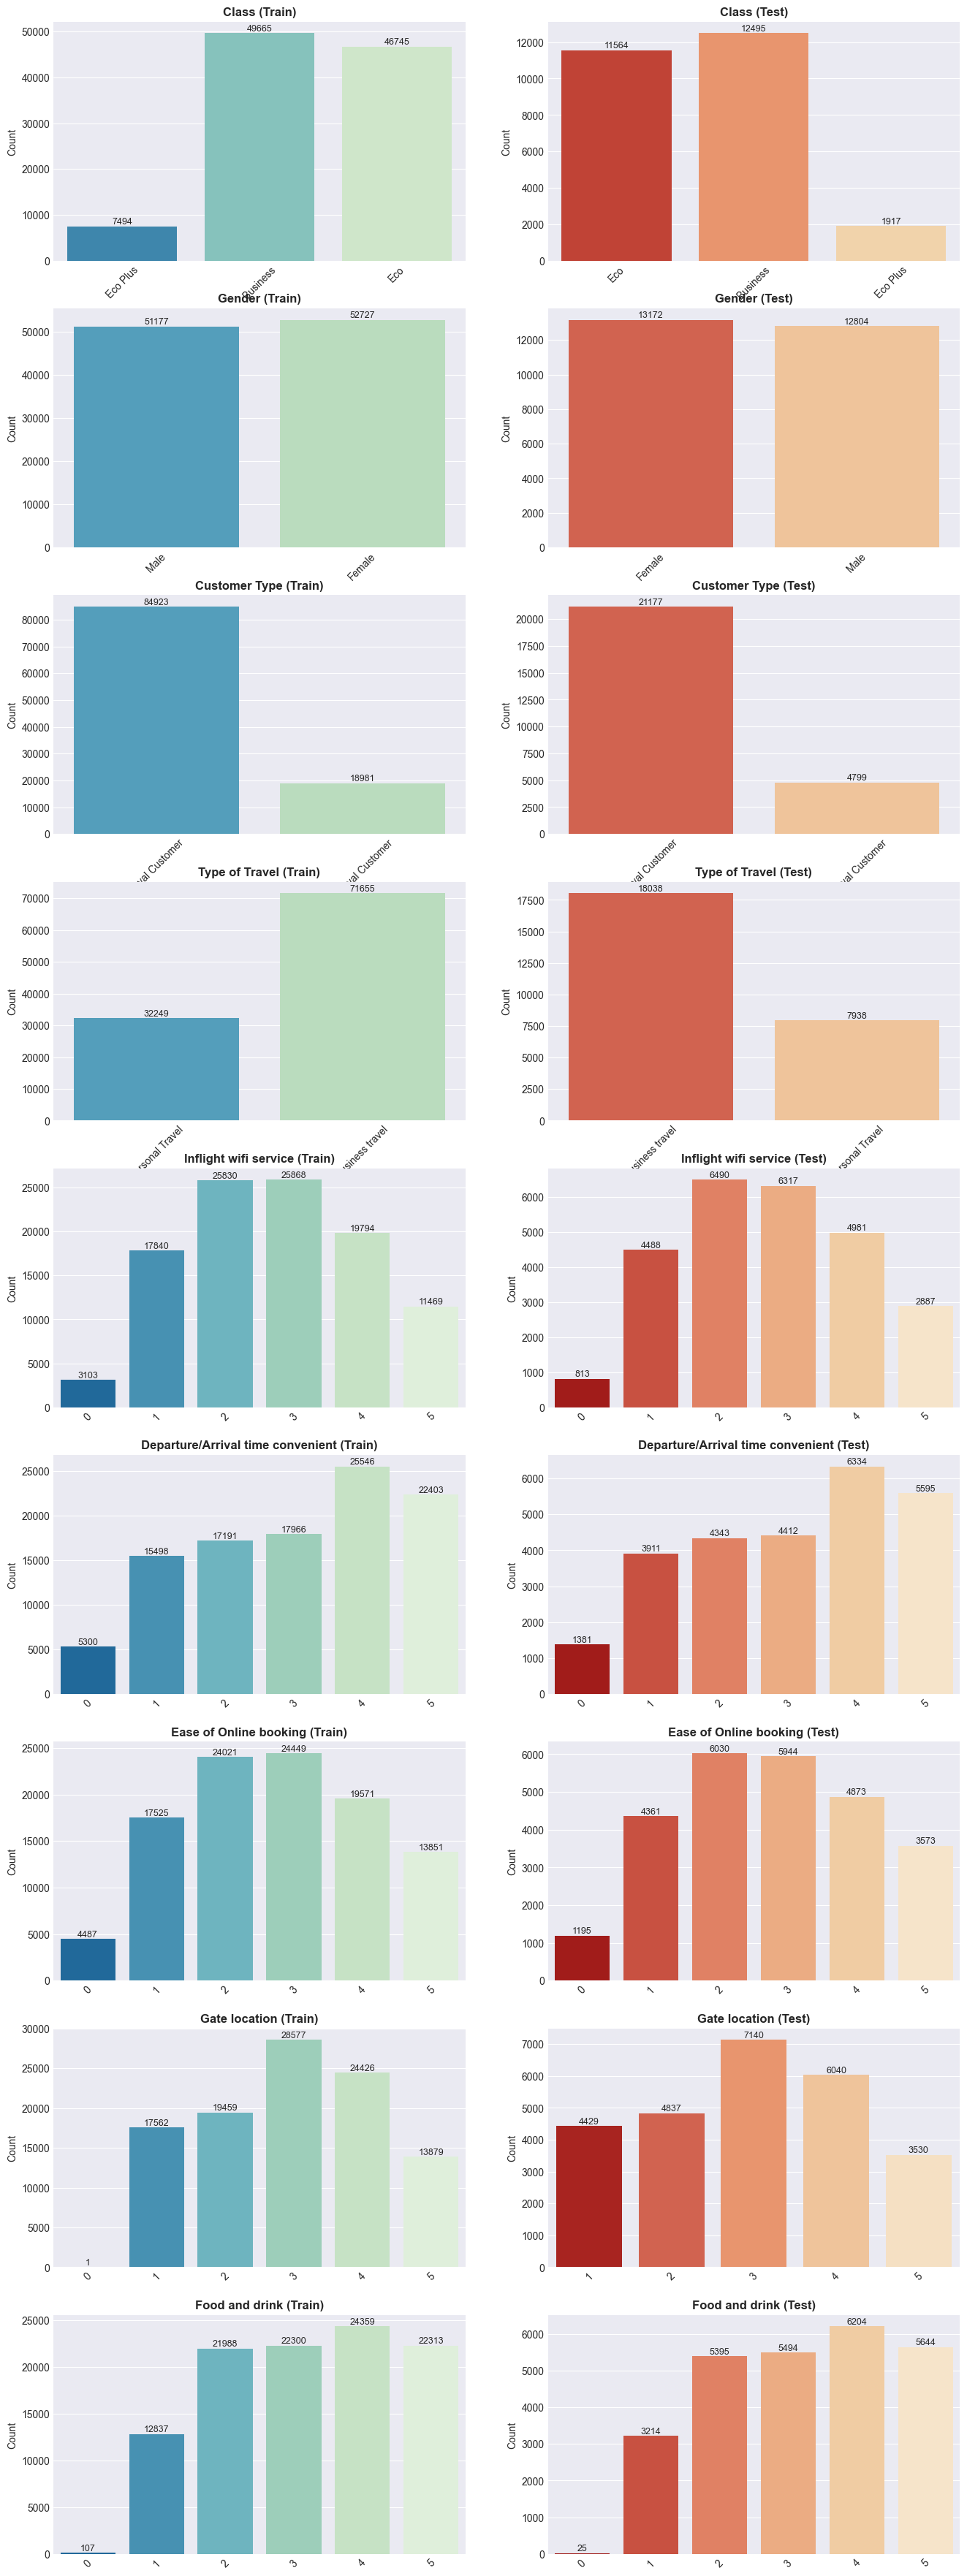

In [27]:
# Plot categorical distributions
print("Plotting categorical feature distributions...")
Plotter.plot_categorical_distributions(df_train[cat_cols], df_test[cat_cols], cat_cols, n_cols=2)

2026-01-20 18:13:34,149 - src.utils.logger - INFO - Plotting correlation heatmaps


Plotting correlation heatmaps...


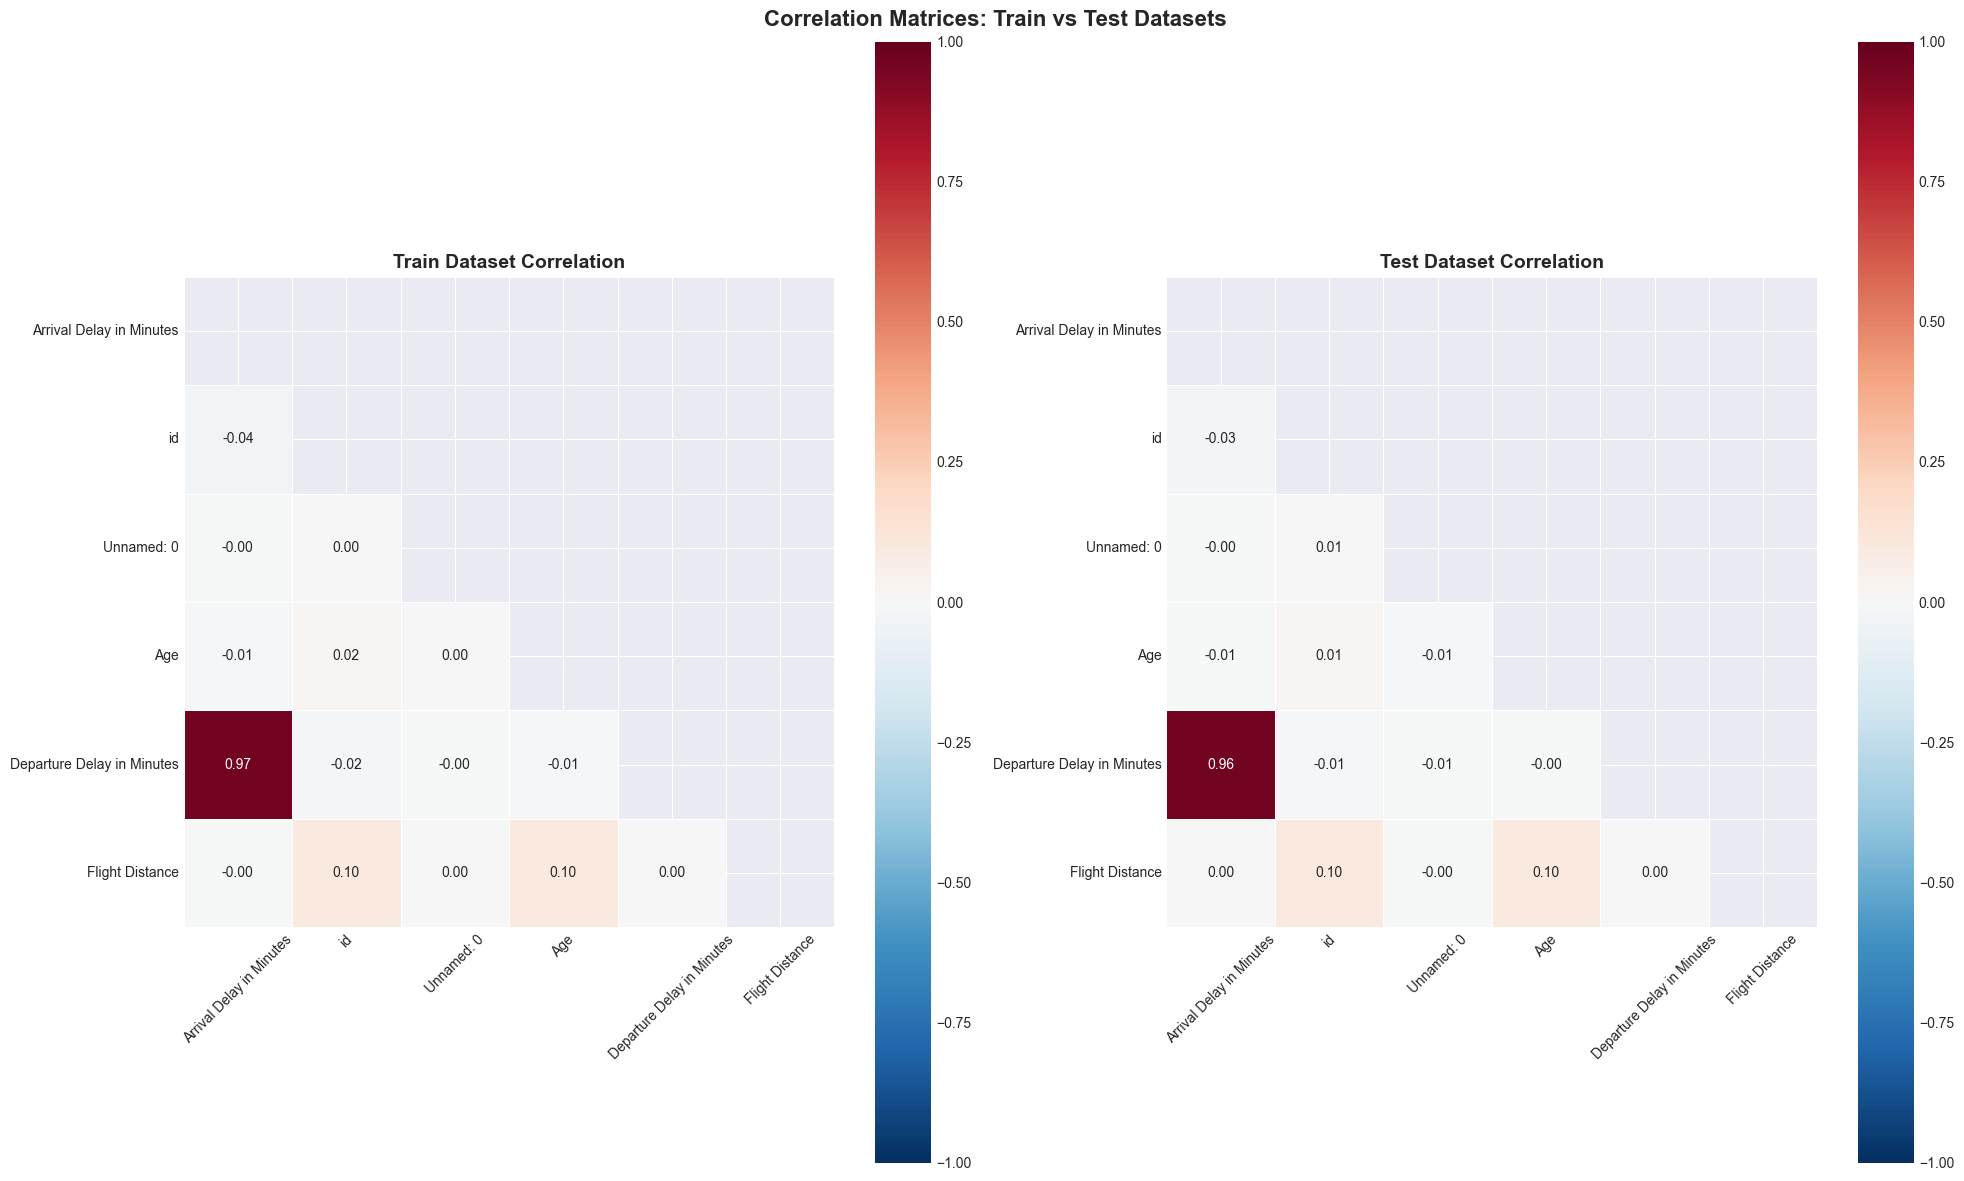

In [26]:
# Plot correlation heatmaps
print("Plotting correlation heatmaps...")
Plotter.plot_correlation_heatmap(df_train[num_cols], df_test[num_cols], num_cols)

2026-01-20 18:07:16,927 - src.utils.logger - INFO - Plotting target variable distribution: satisfaction


Plotting target variable distribution...


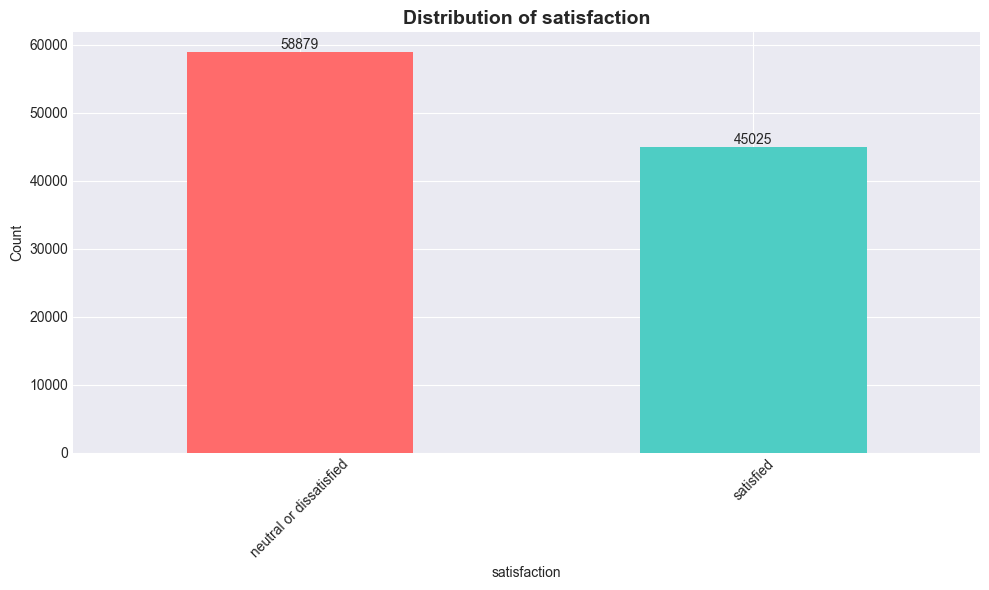

In [25]:
# Plot target distribution
print("Plotting target variable distribution...")
Plotter.plot_target_distribution(df_train, TARGET_COLUMN)

## 7. Key Insights

Summary of findings from EDA

In [ ]:
insights = """
=== KEY INSIGHTS FROM EDA ===

1. DATA SHAPE:
   - Training: 103,904 rows × 25 columns
   - Test: 25,976 rows × 25 columns

2. MISSING VALUES:
   - 'Departure Delay in Minutes' has some missing values
   - All other columns are complete

3. DUPLICATES:
   - No duplicate rows found

4. FEATURE DISTRIBUTIONS:
   - Numerical: Age is approximately normal
   - Numerical: Delays and distance are right-skewed
   - Categorical: Mostly balanced except for some service ratings

5. TARGET VARIABLE:
   - 'satisfaction' is binary: satisfied vs neutral/dissatisfied
   - Roughly balanced distribution

6. CORRELATIONS:
   - Strong positive correlation between arrival and departure delays
   - Service ratings are moderately correlated with each other

NEXT STEP: Proceed to preprocessing and feature engineering
"""

print(insights)


=== KEY INSIGHTS FROM EDA ===

1. DATA SHAPE:
   - Training: 103,904 rows × 25 columns
   - Test: 25,976 rows × 25 columns

2. MISSING VALUES:
   - 'Departure Delay in Minutes' has some missing values
   - All other columns are complete

3. DUPLICATES:
   - No duplicate rows found

4. FEATURE DISTRIBUTIONS:
   - Numerical: Age is approximately normal
   - Numerical: Delays and distance are right-skewed
   - Categorical: Mostly balanced except for some service ratings

5. TARGET VARIABLE:
   - 'satisfaction' is binary: satisfied vs neutral/dissatisfied
   - Roughly balanced distribution

6. CORRELATIONS:
   - Strong positive correlation between arrival and departure delays
   - Service ratings are moderately correlated with each other

NEXT STEP: Proceed to preprocessing and feature engineering



## 8. Save Data for Next Stage

Save information needed for preprocessing

In [ ]:
# Save column information for reference
column_info = {
    'categorical': cat_cols,
    'numerical': num_cols,
    'target': TARGET_COLUMN
}

print("Column information prepared for preprocessing stage")
print(f"Categorical columns: {len(cat_cols)}")
print(f"Numerical columns: {len(num_cols)}")
print(f"Target column: {TARGET_COLUMN}")

Column information prepared for preprocessing stage
Categorical columns: 18
Numerical columns: 6
Target column: satisfaction
